# Анализ игровой индустрии


# Описание проекта

Вы работаете в интернет-магазине «Стримчик», который продаёт по всему миру компьютерные игры. Из открытых источников доступны исторические данные о продажах игр, оценки пользователей и экспертов, жанры и платформы (например, Xbox или PlayStation). Вам нужно выявить определяющие успешность игры закономерности. Это позволит сделать ставку на потенциально популярный продукт и спланировать рекламные кампании.
Перед вами данные до 2016 года. Представим, что сейчас декабрь 2016 г., и вы планируете кампанию на 2017-й. Нужно отработать принцип работы с данными. Неважно, прогнозируете ли вы продажи на 2017 год по данным 2016-го или же 2027-й — по данным 2026 года.
В наборе данных попадается аббревиатура ESRB (Entertainment Software Rating Board) — это ассоциация, определяющая возрастной рейтинг компьютерных игр. ESRB оценивает игровой контент и присваивает ему подходящую возрастную категорию, например, «Для взрослых», «Для детей младшего возраста» или «Для подростков».

**Шаг 1.** Откройте файл с данными и изучите общую информацию
Путь к файлу: /datasets/games.csv. 

**Шаг 2.** Подготовьте данные
* Замените названия столбцов (приведите к нижнему регистру);
* Преобразуйте данные в нужные типы. Опишите, в каких столбцах заменили тип данных и почему;
* Обработайте пропуски при необходимости:
    * Объясните, почему заполнили пропуски определённым образом или почему не стали это делать;
    * Опишите причины, которые могли привести к пропускам;
    * Обратите внимание на аббревиатуру 'tbd' в столбце с оценкой пользователей. Отдельно разберите это значение и опишите, как его обработать;
* Посчитайте суммарные продажи во всех регионах и запишите их в отдельный столбец.

**Шаг 3.** Проведите исследовательский анализ данных
* Посмотрите, сколько игр выпускалось в разные годы. Важны ли данные за все периоды?
* Посмотрите, как менялись продажи по платформам. Выберите платформы с наибольшими суммарными продажами и постройте распределение по годам. За какой характерный срок появляются новые и исчезают старые платформы?
* Возьмите данные за соответствующий актуальный период. Актуальный период определите самостоятельно в результате исследования предыдущих вопросов. Основной фактор — эти данные помогут построить прогноз на 2017 год.
* Не учитывайте в работе данные за предыдущие годы.
* Какие платформы лидируют по продажам, растут или падают? Выберите несколько потенциально прибыльных платформ.
* Постройте график «ящик с усами» по глобальным продажам игр в разбивке по платформам. Опишите результат.
* Посмотрите, как влияют на продажи внутри одной популярной платформы отзывы пользователей и критиков. Постройте диаграмму рассеяния и посчитайте корреляцию между отзывами и продажами. Сформулируйте выводы.
* Соотнесите выводы с продажами игр на других платформах.
* Посмотрите на общее распределение игр по жанрам. Что можно сказать о самых прибыльных жанрах? Выделяются ли жанры с высокими и низкими продажами?
**Шаг 4.** Составьте портрет пользователя каждого региона
 Определите для пользователя каждого региона (NA, EU, JP):
* Самые популярные платформы (топ-5). Опишите различия в долях продаж.
* Самые популярные жанры (топ-5). Поясните разницу.
* Влияет ли рейтинг ESRB на продажи в отдельном регионе?
**Шаг 5.** 
Проверьте гипотезы
* Средние пользовательские рейтинги платформ Xbox One и PC одинаковые;
* Средние пользовательские рейтинги жанров Action (англ. «действие», экшен-игры) и Sports (англ. «спортивные соревнования») разные.
 Задайте самостоятельно пороговое значение alpha.
Поясните:
* Как вы сформулировали нулевую и альтернативную гипотезы;
* Какой критерий применили для проверки гипотез и почему.
**Шаг 6.** 
Напишите общий вывод
**Оформление:** Выполните задание в Jupyter Notebook. Заполните программный код в ячейках типа code, текстовые пояснения — в ячейках типа markdown. Примените форматирование и заголовки.
_**Описание данных**_
* Name — название игры
* Platform — платформа
* Year_of_Release — год выпуска
* Genre — жанр игры
* NA_sales — продажи в Северной Америке (миллионы проданных копий)
* EU_sales — продажи в Европе (миллионы проданных копий)
* JP_sales — продажи в Японии (миллионы проданных копий)
* Other_sales — продажи в других странах (миллионы проданных копий)
* Critic_Score — оценка критиков (максимум 100)
* User_Score — оценка пользователей (максимум 10)
* Rating — рейтинг от организации ESRB (англ. Entertainment Software Rating Board). Эта ассоциация определяет рейтинг компьютерных игр и присваивает им подходящую возрастную категорию.
Данные за 2016 год могут быть неполными.

## **Шаг 1.** Откройте файл с данными и изучите общую информацию

In [1]:
from pymystem3 import Mystem
m = Mystem()

from scipy import stats as st
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

In [2]:
df = pd.read_csv("/datasets/games.csv", sep=",")

print(df.info())
display(df.describe())

display(df)
for column in df.columns:
     display(df[column].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB
None


,Year_of_Release,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score
count,16446.000000,16715.000000,16715.000000,16715.000000,16715.000000,8137.000000
mean,2006.484616,0.263377,0.145060,0.077617,0.047342,68.967679
std,5.877050,0.813604,0.503339,0.308853,0.186731,13.938165
min,1980.000000,0.000000,0.000000,0.000000,0.000000,13.000000
25%,2003.000000,0.000000,0.000000,0.000000,0.000000,60.000000
50%,2007.000000,0.080000,0.020000,0.000000,0.010000,71.000000
75%,2010.000000,0.240000,0.110000,0.040000,0.030000,79.000000
max,2016.000000,41.360000,28.960000,10.220000,10.570000,98.000000


,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
16710,Samurai Warriors: Sanada Maru,PS3,2016.0,Action,0.00,0.00,0.01,0.00,NaN,NaN,NaN
16711,LMA Manager 2007,X360,2006.0,Sports,0.00,0.01,0.00,0.00,NaN,NaN,NaN
16712,Haitaka no Psychedelica,PSV,2016.0,Adventure,0.00,0.00,0.01,0.00,NaN,NaN,NaN
16713,Spirits & Spells,GBA,2003.0,Platform,0.01,0.00,0.00,0.00,NaN,NaN,NaN


Need for Speed: Most Wanted       12
Ratatouille                        9
Madden NFL 07                      9
FIFA 14                            9
LEGO Marvel Super Heroes           9
                                  ..
TouchMaster: Connect               1
Gods Eater Burst                   1
Lucky Luke                         1
Garfield: The Search for Pooky     1
Critical Depth                     1
Name: Name, Length: 11559, dtype: int64

PS2     2161
DS      2151
PS3     1331
Wii     1320
X360    1262
PSP     1209
PS      1197
PC       974
XB       824
GBA      822
GC       556
3DS      520
PSV      430
PS4      392
N64      319
XOne     247
SNES     239
SAT      173
WiiU     147
2600     133
NES       98
GB        98
DC        52
GEN       29
NG        12
WS         6
SCD        6
3DO        3
TG16       2
PCFX       1
GG         1
Name: Platform, dtype: int64

...

0.00    10514
0.02      741
0.01      706
0.03      546
0.04      397
        ...  
3.84        1
1.17        1
3.03        1
2.66        1
1.71        1
Name: JP_sales, Length: 244, dtype: int64

0.00    6601
0.01    3464
0.02    1618
0.03     926
0.04     654
        ... 
0.72       1
2.11       1
0.96       1
1.48       1
3.96       1
Name: Other_sales, Length: 155, dtype: int64

70.0    256
71.0    254
75.0    245
78.0    240
73.0    238
       ... 
29.0      3
13.0      1
22.0      1
17.0      1
21.0      1
Name: Critic_Score, Length: 82, dtype: int64

tbd    2424
7.8     324
8       290
8.2     282
8.3     254
       ... 
0.6       2
2.3       2
0.3       2
0         1
9.7       1
Name: User_Score, Length: 96, dtype: int64

E       3990
T       2961
M       1563
E10+    1420
EC         8
K-A        3
RP         3
AO         1
Name: Rating, dtype: int64

In [3]:
df.head()

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


Дан Датафрейм состоящий из 16715 строк и 11 колонок. Здесь инфо по различным компьютерным играм, плотформы, год выпуска, жанр, данные о продажах, популярности в разных регионах.

* Имеются пропуски в данных, с ними нужно будет поработать
* Названия колонок не в змеином регистре
* Ряд колонок имеет неверный тип

## Шаг 2. Подготовка данных.

###  Заменим названия столбцов (приведем к нижнему регистру)

In [4]:
# df.columns = ['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales',
#        'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating']
    
print(df.columns)
columns = []
for c in df.columns:
    columns.append(c.lower())
df.columns = columns
print(df.columns)

Index(['Name', 'Platform', 'Year_of_Release', 'Genre', 'NA_sales', 'EU_sales',
       'JP_sales', 'Other_sales', 'Critic_Score', 'User_Score', 'Rating'],
      dtype='object')
Index(['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales',
       'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating'],
      dtype='object')


### Обработка пропусков

In [5]:
df

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
16710,Samurai Warriors: Sanada Maru,PS3,2016.0,Action,0.00,0.00,0.01,0.00,NaN,NaN,NaN
16711,LMA Manager 2007,X360,2006.0,Sports,0.00,0.01,0.00,0.00,NaN,NaN,NaN
16712,Haitaka no Psychedelica,PSV,2016.0,Adventure,0.00,0.00,0.01,0.00,NaN,NaN,NaN
16713,Spirits & Spells,GBA,2003.0,Platform,0.01,0.00,0.00,0.00,NaN,NaN,NaN


*Поменяем в столбце year_of_release тип на Int64, так как год пишут всегда целым числом (float - это совсем не гигиенично)*

In [6]:
df['year_of_release'] = df['year_of_release'].astype('Int64')

In [7]:
df['year_of_release'].dtype

Int64Dtype()

*В других столбцах менять типы нет необходимости (пока)*

### Обработка пропусков

#### Столбец name

*Посмотрим пропущенные значения*

In [8]:
df.query('name.isna()')

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
659,NaN,GEN,1993,NaN,1.78,0.53,0.00,0.08,NaN,NaN,NaN
14244,NaN,GEN,1993,NaN,0.00,0.00,0.03,0.00,NaN,NaN,NaN


In [9]:
df.query('platform=="GEN" and year_of_release==1993')

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
659,NaN,GEN,1993,NaN,1.78,0.53,0.00,0.08,NaN,NaN,NaN
7885,Shining Force II,GEN,1993,Strategy,0.00,0.00,0.19,0.00,NaN,NaN,NaN
8893,Super Street Fighter II,GEN,1993,Fighting,0.00,0.00,0.15,0.00,NaN,NaN,NaN
11986,Ecco: The Tides of Time,GEN,1993,Adventure,0.00,0.00,0.07,0.00,NaN,NaN,NaN
12098,Street Fighter II': Special Champion Edition (...,GEN,1993,Action,0.00,0.00,0.07,0.00,NaN,NaN,NaN
12264,Streets of Rage 3,GEN,1993,Action,0.00,0.00,0.07,0.00,NaN,NaN,NaN
12984,Dynamite Headdy,GEN,1993,Platform,0.00,0.00,0.05,0.00,NaN,NaN,NaN
13343,Beyond Oasis,GEN,1993,Role-Playing,0.00,0.00,0.05,0.00,NaN,NaN,NaN
14244,NaN,GEN,1993,NaN,0.00,0.00,0.03,0.00,NaN,NaN,NaN


*Не вижу возможности узнать имя игр, да и в других столбцах тоже есть пропуски , поэтому удалим эти 2 строки, так как 2 строки против 15 тысяч незначительно мало*

In [10]:
print('До удаления',len(df))
df.dropna(subset=['name'], inplace=True)
df.reset_index(inplace=True,drop=True)
print('После удаления',len(df))

До удаления 16715
После удаления 16713


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16713 entries, 0 to 16712
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16713 non-null  object 
 2   year_of_release  16444 non-null  Int64  
 3   genre            16713 non-null  object 
 4   na_sales         16713 non-null  float64
 5   eu_sales         16713 non-null  float64
 6   jp_sales         16713 non-null  float64
 7   other_sales      16713 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       10014 non-null  object 
 10  rating           9949 non-null   object 
dtypes: Int64(1), float64(5), object(5)
memory usage: 1.4+ MB


*Хоть названия игр часто бывают оригинальными и возможно не подпадут под лемматизацию, всё же попробуем это сделать, чтобы найти одни и теже имена , которые написаны по разному*

In [12]:
# Функция получает строку - лемматизирует её, затем собирает и возвращает результат
def lemm_list(st):
    w = m.lemmatize(st)
    w.pop()
    return ''.join(w)

df['lemm_name'] = df['name'].apply(lemm_list)
df

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,lemm_name
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76.0,8,E,Wii Sports
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN,Super Mario Bros.
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E,Mario Kart Wii
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80.0,8,E,Wii Sports Resort
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN,Pokemon Red/Pokemon Blue
...,...,...,...,...,...,...,...,...,...,...,...,...
16708,Samurai Warriors: Sanada Maru,PS3,2016,Action,0.00,0.00,0.01,0.00,NaN,NaN,NaN,Samurai Warriors: Sanada Maru
16709,LMA Manager 2007,X360,2006,Sports,0.00,0.01,0.00,0.00,NaN,NaN,NaN,LMA Manager 2007
16710,Haitaka no Psychedelica,PSV,2016,Adventure,0.00,0.00,0.01,0.00,NaN,NaN,NaN,Haitaka no Psychedelica
16711,Spirits & Spells,GBA,2003,Platform,0.01,0.00,0.00,0.00,NaN,NaN,NaN,Spirits & Spells


*А теперь посчитаем количество строк ".value_counts()" 
в обоих столбцах name и lemm_name, если кол-во совпадёт, то повторов нет*

In [13]:
print(len(df['name'].value_counts() ), len(df['lemm_name'].value_counts()))

11559 11558


*Всего 1 значение совпало, то есть в ".value_counts()" оно было = 1, а затем присоединилось к другому*

In [14]:
lemm_name = df['lemm_name'].value_counts()
lemm_name

Need for Speed: Most Wanted      12
FIFA 14                           9
Madden NFL 07                     9
LEGO Marvel Super Heroes          9
Ratatouille                       9
                                 ..
Cake Mania 3                      1
Harvest Moon DS (jp sales         1
Jikkyou Powerful Pro Yakyuu 5     1
Gal Gun                           1
Jampack Volume 13 (RP-M           1
Name: lemm_name, Length: 11558, dtype: int64

In [15]:

df.reset_index(drop=True)

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,lemm_name
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76.0,8,E,Wii Sports
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN,Super Mario Bros.
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E,Mario Kart Wii
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80.0,8,E,Wii Sports Resort
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN,Pokemon Red/Pokemon Blue
...,...,...,...,...,...,...,...,...,...,...,...,...
16708,Samurai Warriors: Sanada Maru,PS3,2016,Action,0.00,0.00,0.01,0.00,NaN,NaN,NaN,Samurai Warriors: Sanada Maru
16709,LMA Manager 2007,X360,2006,Sports,0.00,0.01,0.00,0.00,NaN,NaN,NaN,LMA Manager 2007
16710,Haitaka no Psychedelica,PSV,2016,Adventure,0.00,0.00,0.01,0.00,NaN,NaN,NaN,Haitaka no Psychedelica
16711,Spirits & Spells,GBA,2003,Platform,0.01,0.00,0.00,0.00,NaN,NaN,NaN,Spirits & Spells


In [16]:
# # Вариант1
# for i in df.index:
#     n = df.loc[i,'name']
#     n_lem = df.loc[i,'lemm_name']
#     if (df.query('name==@n')['name'].count()) != (df.query('lemm_name==@n_lem')['lemm_name'].count()):
#         print(i, df.loc[i,'name'], df.loc[i,'lemm_name'])

# Вариант2
def seach_lem(st):
    i = st
    n = df.loc[i,'name']
    n_lem = df.loc[i,'lemm_name']
    if (df.query('name==@n')['name'].count()) != (df.query('lemm_name==@n_lem')['lemm_name'].count()):
        print(i, df.loc[i,'name'], df.loc[i,'lemm_name'])
df.reset_index()['index'].apply(seach_lem)

# Оба варианта работают очень долго 30-50сек

6444 Love Plus Love Plus
6945 Love Plus + Love Plus


0        None
1        None
2        None
3        None
4        None
         ... 
16708    None
16709    None
16710    None
16711    None
16712    None
Name: index, Length: 16713, dtype: object

In [17]:

df.loc[[6444,6945]]

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,lemm_name
6444,Love Plus,DS,2009,Simulation,0.0,0.0,0.26,0.0,NaN,NaN,NaN,Love Plus
6945,Love Plus +,DS,2010,Simulation,0.0,0.0,0.23,0.0,NaN,NaN,NaN,Love Plus


*Cтранные 2 строки вроде одна и таже игра, одинаковая платформа, но 2 разных года выпуска 2009 и 2010, да еще и plus+, может это какое-то обновление? А посмотрим что скажет Яндекс по этому поводу?*

http://gamebomb.ru/games/15179 LovePlus – симулятор знакомств для Nintendo DS, вышедший в 2009 году. После релиза последовали обновления и сиквелы, в том числе игра для iOS.
LovePlus+ – версия игры с новым контентом. Почти всё из оригинальной версии представлено в LovePlus+, наряду со многими новыми способами взаимодействия с девушками. Из оригинальной игры в LovePlus+ можно переносить данные.

LovePlus+ и LovePlus - будем считать, что это 2 разные игры. В остальном столбец в порядке

*Удалим новый столбец он больше не пригодится*

In [18]:
df.drop('lemm_name', axis=1, inplace=True)

In [19]:

df.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


#### Столбец platform

*Пропусков здесь нет, проверим корректность данных*

In [20]:
df['platform'].value_counts().sort_index()

2600     133
3DO        3
3DS      520
DC        52
DS      2151
GB        98
GBA      822
GC       556
GEN       27
GG         1
N64      319
NES       98
NG        12
PC       974
PCFX       1
PS      1197
PS2     2161
PS3     1331
PS4      392
PSP     1209
PSV      430
SAT      173
SCD        6
SNES     239
TG16       2
WS         6
Wii     1320
WiiU     147
X360    1262
XB       824
XOne     247
Name: platform, dtype: int64

С платформами всё в порядке, столбец корректен.

#### Столбец year_of_release

In [21]:
df['year_of_release'].value_counts()

2008    1427
2009    1426
2010    1255
2007    1197
2011    1136
2006    1006
2005     939
2002     829
2003     775
2004     762
2012     653
2015     606
2014     581
2013     544
2016     502
2001     482
1998     379
2000     350
1999     338
1997     289
1996     263
1995     219
1994     121
1993      60
1981      46
1992      43
1991      41
1982      36
1986      21
1983      17
1989      17
1990      16
1987      16
1988      15
1985      14
1984      14
1980       9
Name: year_of_release, dtype: Int64

*С данными всё Ok, займемся пропусками*

In [22]:
display(df[df['year_of_release'].isna()])
print('Кол-во пропусков =', df['year_of_release'].isna().sum())

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
183,Madden NFL 2004,PS2,<NA>,Sports,4.26,0.26,0.01,0.71,94.0,8.5,E
377,FIFA Soccer 2004,PS2,<NA>,Sports,0.59,2.36,0.04,0.51,84.0,6.4,E
456,LEGO Batman: The Videogame,Wii,<NA>,Action,1.80,0.97,0.00,0.29,74.0,7.9,E10+
475,wwe Smackdown vs. Raw 2006,PS2,<NA>,Fighting,1.57,1.02,0.00,0.41,NaN,NaN,NaN
609,Space Invaders,2600,<NA>,Shooter,2.36,0.14,0.00,0.03,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
16371,PDC World Championship Darts 2008,PSP,<NA>,Sports,0.01,0.00,0.00,0.00,43.0,tbd,E10+
16403,Freaky Flyers,GC,<NA>,Racing,0.01,0.00,0.00,0.00,69.0,6.5,T
16446,Inversion,PC,<NA>,Shooter,0.01,0.00,0.00,0.00,59.0,6.7,M
16456,Hakuouki: Shinsengumi Kitan,PS3,<NA>,Adventure,0.01,0.00,0.00,0.00,NaN,NaN,NaN


Кол-во пропусков = 269


Всего в колонке "year_of_release" 269 пропущенных значений.
Строк с пропусками в годах выпуска не так много и их можно исключить,
ведь они в любом случае не попадут в актуальный период.

In [23]:
#удаление пропусков
df = df.dropna(subset=['year_of_release'])

In [24]:
#проверка пропусков
df.isna().sum()

name                  0
platform              0
year_of_release       0
genre                 0
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8461
user_score         6605
rating             6676
dtype: int64

#### Столбец genre

In [25]:
df['genre'].value_counts().sort_index()

Action          3307
Adventure       1293
Fighting         837
Misc            1721
Platform         878
Puzzle           569
Racing          1226
Role-Playing    1481
Shooter         1296
Simulation       857
Sports          2306
Strategy         673
Name: genre, dtype: int64

*Пропусков нет, имена жанров в порядке, хороший столбец. Всё корректно*

#### Столбец na_sales

In [26]:
df['na_sales'].describe()

count    16444.000000
mean         0.264012
std          0.818378
min          0.000000
25%          0.000000
50%          0.080000
75%          0.240000
max         41.360000
Name: na_sales, dtype: float64

*Всё корректно.*

#### Столбец eu_sales

In [27]:
df['eu_sales'].describe()

count    16444.000000
mean         0.145930
std          0.506716
min          0.000000
25%          0.000000
50%          0.020000
75%          0.110000
max         28.960000
Name: eu_sales, dtype: float64

*Всё корректно.*

#### Столбец jp_sales

In [28]:
df['jp_sales'].describe()

count    16444.000000
mean         0.078487
std          0.311100
min          0.000000
25%          0.000000
50%          0.000000
75%          0.040000
max         10.220000
Name: jp_sales, dtype: float64

*Всё корректно.*

#### Столбец other_sales

In [29]:
df['other_sales'].describe()

count    16444.000000
mean         0.047594
std          0.188005
min          0.000000
25%          0.000000
50%          0.010000
75%          0.030000
max         10.570000
Name: other_sales, dtype: float64

*Всё корректно.*

#### Столбцы critic_score и user_score

In [30]:
display(df['critic_score'].describe())
display(df['critic_score'].value_counts())

count    7983.000000
mean       68.994363
std        13.920060
min        13.000000
25%        60.000000
50%        71.000000
75%        79.000000
max        98.000000
Name: critic_score, dtype: float64

70.0    252
71.0    248
75.0    240
80.0    235
73.0    234
       ... 
29.0      3
20.0      3
13.0      1
17.0      1
21.0      1
Name: critic_score, Length: 81, dtype: int64

*Данные столбца critic_score корректны*

*Рассмотрим столбец user_score*

In [31]:
display(df[['user_score']].describe())
display(df['user_score'].value_counts())

,user_score
count,9839
unique,96
top,tbd
freq,2376


tbd    2376
7.8     322
8       285
8.2     276
8.3     252
       ... 
0.6       2
2.3       2
0.3       2
0         1
9.7       1
Name: user_score, Length: 96, dtype: int64

*Посмотрим в интернете, что значит "tbd"
https://fb.ru/article/171345/tbd---chto-znachit-eto-sokraschenie
...расшифровывается очень просто - To Be Determined, то есть "Будет определено".
Выведем на экран строки с "tbd"*

In [32]:
display(df[df['user_score']=="tbd"])

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
119,Zumba Fitness,Wii,2010,Sports,3.45,2.59,0.0,0.66,NaN,tbd,E
301,Namco Museum: 50th Anniversary,PS2,2005,Misc,2.08,1.35,0.0,0.54,61.0,tbd,E10+
520,Zumba Fitness 2,Wii,2011,Sports,1.51,1.03,0.0,0.27,NaN,tbd,T
645,uDraw Studio,Wii,2010,Misc,1.65,0.57,0.0,0.20,71.0,tbd,E
717,Just Dance Kids,Wii,2010,Misc,1.52,0.54,0.0,0.18,NaN,tbd,E
...,...,...,...,...,...,...,...,...,...,...,...
16693,Planet Monsters,GBA,2001,Action,0.01,0.00,0.0,0.00,67.0,tbd,E
16695,Bust-A-Move 3000,GC,2003,Puzzle,0.01,0.00,0.0,0.00,53.0,tbd,E
16696,Mega Brain Boost,DS,2008,Puzzle,0.01,0.00,0.0,0.00,48.0,tbd,E
16702,Plushees,DS,2008,Simulation,0.01,0.00,0.0,0.00,NaN,tbd,E


*Было предположение, что это рейтинги игр, вышедших в последний год, - поэтому рейтинг и не определен. Но предположение оказалось ложным. Закономерность появления "tbd" не прослеживается. Поэтому заменим их на NaN и тогда уже обработаем оба столбца вместе. И поменяем тип на float*

In [33]:
#обработаем пропуски в столбце 'critic_score'
df[df['critic_score'].isna()]

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN
5,Tetris,GB,1989,Puzzle,23.20,2.26,4.22,0.58,NaN,NaN,NaN
9,Duck Hunt,NES,1984,Shooter,26.93,0.63,0.28,0.47,NaN,NaN,NaN
10,Nintendogs,DS,2005,Simulation,9.05,10.95,1.93,2.74,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
16708,Samurai Warriors: Sanada Maru,PS3,2016,Action,0.00,0.00,0.01,0.00,NaN,NaN,NaN
16709,LMA Manager 2007,X360,2006,Sports,0.00,0.01,0.00,0.00,NaN,NaN,NaN
16710,Haitaka no Psychedelica,PSV,2016,Adventure,0.00,0.00,0.01,0.00,NaN,NaN,NaN
16711,Spirits & Spells,GBA,2003,Platform,0.01,0.00,0.00,0.00,NaN,NaN,NaN


Количество пропусков сильно большое. Лучше их не удалять, а заменить на значение "-1"
Допустимо заполнение числовой заглушкой , но в таком случае это обязывает нас фильтровать её каждый раз при подсчете показателей.
Пробовала заменить на "Unknown", ни возникли проблемы с визуализацией зависимость продаж от отзывов из-за формата

In [34]:
#заменим пропуски NaN на значение 
df['critic_score'] = df['critic_score'].fillna(-1)

/tmp/ipykernel_381/86374397.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['critic_score'] = df['critic_score'].fillna(-1)


In [35]:
#обработаем пропуски в столбце 'user_score'
df[df['user_score'].isna()]

df.loc[df['user_score'] == 'tbd', 'user_score'] = -1
df.loc[df['user_score'] == 'Unknown', 'user_score'] = -1
df['user_score'] = df['user_score'].astype(float)

# вариант 2 
# df['user_score'] = pd.to-numeric(df['user_score'], errors = 'coerce')

/opt/conda/lib/python3.9/site-packages/pandas/core/indexing.py:1720: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_column(loc, value, pi)
/tmp/ipykernel_381/3360276983.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['user_score'] = df['user_score'].astype(float)


 Количество пропусков также слишком большое, точной информацией заменить их не представляется возможным, так что заменим также на значение -1. В столбце имеется оценка tbd и игнорировать это нельзя, обозначим как "-1"

In [36]:

df['user_score'].value_counts() 

-1.0    2376
 7.8     322
 8.0     285
 8.2     276
 8.3     252
        ... 
 0.7       2
 0.2       2
 1.0       2
 9.7       1
 0.0       1
Name: user_score, Length: 96, dtype: int64

#### Столбец rating

In [37]:

df.head(10)

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76.0,8.0,E
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,-1.0,NaN,NaN
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80.0,8.0,E
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,-1.0,NaN,NaN
5,Tetris,GB,1989,Puzzle,23.20,2.26,4.22,0.58,-1.0,NaN,NaN
6,New Super Mario Bros.,DS,2006,Platform,11.28,9.14,6.50,2.88,89.0,8.5,E
7,Wii Play,Wii,2006,Misc,13.96,9.18,2.93,2.84,58.0,6.6,E
8,New Super Mario Bros. Wii,Wii,2009,Platform,14.44,6.94,4.70,2.24,87.0,8.4,E
9,Duck Hunt,NES,1984,Shooter,26.93,0.63,0.28,0.47,-1.0,NaN,NaN


In [38]:
print(df['rating'].value_counts(), df['rating'].isna().sum())

E       3921
T       2905
M       1536
E10+    1393
EC         8
K-A        3
AO         1
RP         1
Name: rating, dtype: int64 6676


In [39]:
#заменим пропуски NaN на значение 'unknown'
df['rating'] = df['rating'].fillna(-1)

/tmp/ipykernel_381/4265431331.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['rating'] = df['rating'].fillna(-1)


In [40]:
#проверка на наличие пропусков
df.isna().sum()

name                  0
platform              0
year_of_release       0
genre                 0
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score          0
user_score         6605
rating                0
dtype: int64

**Проверим на дубликаты**

In [41]:
#df.duplicated().sum()

In [42]:
print(df.duplicated(subset=['name', 'platform', 'year_of_release']).sum())
      

1


Всего 1 на такой обьем данных. Позволю себе его проигнорировать

In [43]:
df['name'].unique()

array(['Wii Sports', 'Super Mario Bros.', 'Mario Kart Wii', ...,
       'Woody Woodpecker in Crazy Castle 5', 'LMA Manager 2007',
       'Haitaka no Psychedelica'], dtype=object)

In [44]:
df['platform'].unique()

array(['Wii', 'NES', 'GB', 'DS', 'X360', 'PS3', 'PS2', 'SNES', 'GBA',
       'PS4', '3DS', 'N64', 'PS', 'XB', 'PC', '2600', 'PSP', 'XOne',
       'WiiU', 'GC', 'GEN', 'DC', 'PSV', 'SAT', 'SCD', 'WS', 'NG', 'TG16',
       '3DO', 'GG', 'PCFX'], dtype=object)

In [45]:
df['year_of_release'].unique()

<IntegerArray>
[2006, 1985, 2008, 2009, 1996, 1989, 1984, 2005, 1999, 2007, 2010, 2013, 2004,
 1990, 1988, 2002, 2001, 2011, 1998, 2015, 2012, 2014, 1992, 1997, 1993, 1994,
 1982, 2016, 2003, 1986, 2000, 1995, 1991, 1981, 1987, 1980, 1983]
Length: 37, dtype: Int64

Дубликаты отсутствуют.

### Суммарные продажи во всех регионах - столбец sales

In [46]:
df.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76.0,8.0,E
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,-1.0,NaN,-1
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80.0,8.0,E
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,-1.0,NaN,-1


In [47]:
df['sales'] = df['na_sales'] + df['eu_sales'] + df['jp_sales'] + df['other_sales']
df.head()

/tmp/ipykernel_381/3790518453.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['sales'] = df['na_sales'] + df['eu_sales'] + df['jp_sales'] + df['other_sales']


,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,sales
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76.0,8.0,E,82.54
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,-1.0,NaN,-1,40.24
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E,35.52
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80.0,8.0,E,32.77
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,-1.0,NaN,-1,31.38


### Вывод:

В ходе предобработки в Столбце *name* удалено 2 строки , применяли лемматизацию для поиска схожих имен, но в итоге дубликатов не нашли

Столбец *year_of_release* - Осталось 146 пропусков, удалять строки с ними не будем (пока), возможно пригодятся значения с продажами. Просто запомним, что здесь есть пропуски на будущее.

Столбец *critic_score и user_score* заполнены на 8,7 тыс строк.

Столбец *rating* - Удалось заполнить совсем не много - 437 пропусков.

Оставшиеся пропуски заполнить не вижу возможности (логически/по_смыслу), если заполнять медианами, средними , то это может непредсказуемо отразиться на результатах будущего анализа данных.

Дубликатов не выявленно

Хоть данные очень не полные, придется оставить как есть. Будем использовать для анализа то, что имеем.

По заданию добавлен столбец *sales* с суммой всех продаж в регионах

## Шаг 3. Исследовательский анализ данных

### Сколько игр выпускалось в разные годы. Важны ли данные за все периоды?

In [48]:
time_release = df.groupby('year_of_release')['name'].count().reset_index()
time_release.columns = ['year', 'quantity']
time_release

,year,quantity
0,1980,9
1,1981,46
2,1982,36
3,1983,17
4,1984,14
5,1985,14
6,1986,21
7,1987,16
8,1988,15
9,1989,17


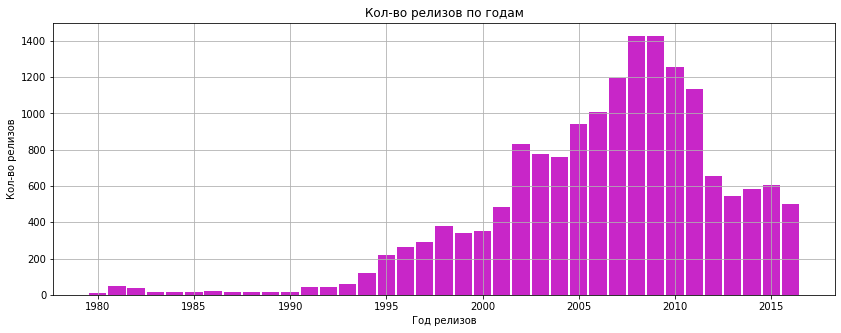

In [49]:
plt.figure(figsize=(14, 5))
plt.bar(time_release['year'], time_release['quantity'], label='Кол-во релизов за год', color='m', alpha=0.85, width=0.9)
plt.xlabel('Год релизов')
plt.ylabel('Кол-во релизов')
plt.grid()
plt.title(f'Кол-во релизов по годам')
# plt.legend()
plt.show();

_**Вывод:** Период до 1994 года характеризуется малой активностью. Хорошо видно, что важный период в релизах игр наступает в 1994 году - и после него начинается бум - компьютерные игры захватывают мир. В 2010 наступает переломный момент и уже в 2012 релизы падают в 2 раза и до 2016 держатся примерно на одно уровне_

### Анализ продаж по платформам

*(Посмотрите, как менялись продажи по платформам. Выберите платформы с наибольшими суммарными продажами и постройте распределение по годам. За какой характерный срок появляются новые и исчезают старые платформы?)*

In [50]:
plf = df.groupby('platform')['sales'].sum().sort_values().reset_index()
plf

,platform,sales
0,PCFX,0.03
1,GG,0.04
2,3DO,0.10
3,TG16,0.16
4,WS,1.42
5,NG,1.44
6,SCD,1.86
7,DC,15.95
8,GEN,28.35
9,SAT,33.59


Возьмем платформы с наибольшими объемами продаж. Построим по ним распределение продаж по годам

In [51]:
popul_platforms = plf.loc[21:30, 'platform'].values
popul_platforms

array(['3DS', 'PSP', 'GBA', 'PS4', 'PS', 'DS', 'Wii', 'PS3', 'X360',
       'PS2'], dtype=object)

In [52]:
# код ревьюера
df.groupby('platform').agg({'sales': 'sum'}).sort_values(by='sales', ascending=False).head(10).index.to_list()

['PS2', 'X360', 'PS3', 'Wii', 'DS', 'PS', 'PS4', 'GBA', 'PSP', '3DS']

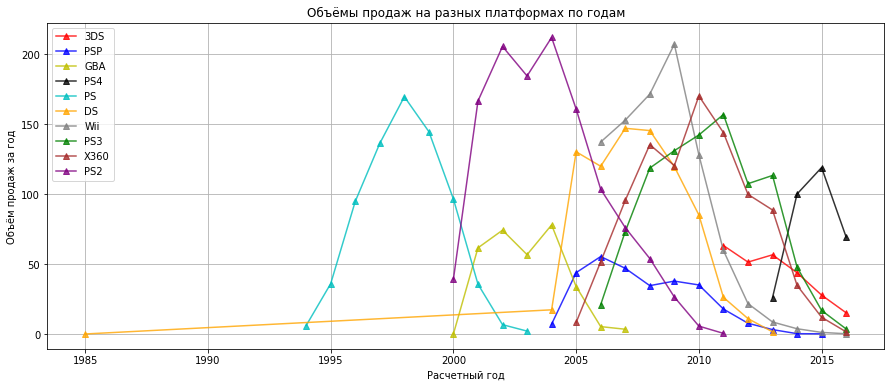

In [53]:
color = ['r','b','y','black','c','orange','grey','green','brown','purple','m','pink','yellow']

plt.figure(figsize=(15, 6))
plt.grid()
plt.title('Объёмы продаж на разных платформах по годам')

mean_year_life = 0
for i in range(0,len(popul_platforms)):
    platform  = df.query('platform == @popul_platforms[@i]').groupby('year_of_release')['sales'].sum()
    mean_year_life += platform.count()
#     plt.plot(platform.index, platform.values, label=popul_platforms[i], color=color[i], alpha=0.8);
#     plt.bar(platform.index+(-3/6 + i/6), platform.values, label=popul_platforms[i], color=color[i], alpha=0.8, width=1/6);
    platform.plot(x=platform.index, y=platform.values, style='-^', color=color[i], \
                  label=popul_platforms[i], alpha=0.8, grid=True);
plt.xlabel('Расчетный год')    
plt.ylabel('Объём продаж за год')
plt.legend()
plt.show();

Подсчитаем срок жизни платформы вручную - расчетное значение

In [54]:
mean_year_life/len(popul_platforms)

9.7

In [55]:
# код ревьюера
df[df['platform'].isin(popul_platforms)].groupby('platform')['year_of_release'].nunique().mean()

9.7

_**Вывод:** Расчетное значение 11,4 года, а из графика видно, что срок активного существования платформ 9-10 лет(если не обращать внимания на минимальные значения по краям), и распределение продаж идет близко к нормальному распределению,Поэтому будем считтать,что срок средний существования платформы - 10-12 лет. Можно выделить из списка платформ - "PC" (компьютеры, наверное), они хоть и не в топах по выручке, но актуальны во все времена. Также надо отметить,что платформа "DS" просуществовала очень длго - до 2013 года._

### Прогноз на 2017 год

(Возьмите данные за соответствующий актуальный период. Актуальный период определите самостоятельно в результате исследования предыдущих вопросов. Основной фактор — эти данные помогут построить прогноз на 2017 год.)

*для прогноза на 2017 год возьмем предыдущий период в 3 года (с 2014 года)*

In [56]:
platform2017 = df.pivot_table(index='year_of_release', columns='platform', values='sales', aggfunc='sum').\
    query('year_of_release>2013').fillna(0).reset_index()
platform2017['year_of_release'] = platform2017['year_of_release'].astype('Int64')

for column in platform2017.columns:
    if platform2017[column].sum()==0:
        platform2017.drop(column, axis=1,inplace=True)

display(platform2017)

platform,year_of_release,3DS,PC,PS3,PS4,PSP,PSV,Wii,WiiU,X360,XOne
0,2014,43.76,13.28,47.76,100.00,0.24,11.90,3.75,22.03,34.74,54.07
1,2015,27.78,8.52,16.82,118.90,0.12,6.25,1.14,16.35,11.96,60.14
2,2016,15.14,5.25,3.60,69.25,0.00,4.25,0.18,4.60,1.52,26.15


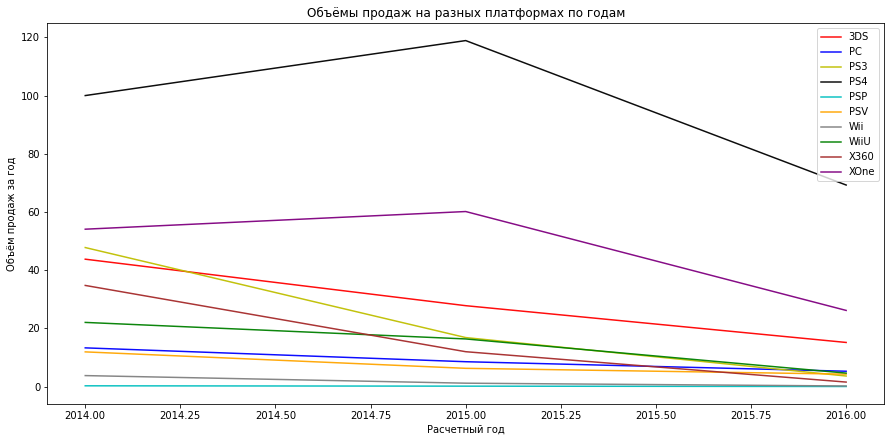

In [57]:

plt.figure(figsize=(15, 7))
plt.grid()
plt.title('Объёмы продаж на разных платформах по годам')

i=0
for column in platform2017.columns[1:]:
    plt.plot(platform2017['year_of_release'].to_list(), platform2017[column].to_list(), label=column, color=color[i], alpha=0.95);
    i+=1 # В верхней строчке выдает ошибку

plt.grid()
plt.xlabel('Расчетный год')    
plt.ylabel('Объём продаж за год')
plt.legend()
plt.show();

_**Вывод:** Видно , что многие популярные платформы, такие как: Wii, PS3, X360, PSP, - прошли свой цикл развития 10-12 лет, и как раз в районе текущего 2016 года завершающий аккорд (другие платформы PS2, DS, GBA, XB, закончилиь еще раньще) - во все эти платформы вкладываться не стоит их развитие закончилось._

*Но есть две платформы PS4 и XOne, которые появились относительно недавно в 2013 году и уже завоевали потребителя в 2014 и 2015 рост, а в 2016 был спад; их жизненный цикл еше не дошёл даже до середины, поэтому будет логично воспользоваться спадом и развивать эти , на данный момент самые перспективные, платформы!*

*Также надо обратить внимание платформу PC , которая существуют уже очень долго и стабильно, она актуальна во все времена (но в небольших объемах).*

Кратко: Флагманы - PS4 и XOne! PSV, WiiU и 3DS - тоже можно продолжать развивать, но в меньших объемах(PSV - развитие идет слабо, поэтому приоритет у WiiU и 3DS); платформа PC - актуальна всегда(но в малых объемах), поэтому надо поддерживать её развитие

*Создадим: список из топ-5 потенциально прибыльных платформ top5_2017 на 2017 год
Список популярных с 2014 года top2014
И data_actual, в который сохраним данные за период с 2014-2016 годы*

In [58]:
top5_2017 = ['PS4', 'XOne', 'WiiU', 'PSV', '3DS']
data_actual = df.query('year_of_release>=2014')
top2014 = df.query('year_of_release>=2014').groupby('platform')['sales'].sum().sort_values(ascending=False).reset_index().head(10)
top2014

,platform,sales
0,PS4,288.15
1,XOne,140.36
2,3DS,86.68
3,PS3,68.18
4,X360,48.22
5,WiiU,42.98
6,PC,27.05
7,PSV,22.40
8,Wii,5.07
9,PSP,0.36


### Глобальные продажи игр в разбивке по платформам

Постройте график «ящик с усами» по глобальным продажам игр в разбивке по платформам. Опишите результат.

In [59]:

top2014

,platform,sales
0,PS4,288.15
1,XOne,140.36
2,3DS,86.68
3,PS3,68.18
4,X360,48.22
5,WiiU,42.98
6,PC,27.05
7,PSV,22.40
8,Wii,5.07
9,PSP,0.36


Возьмем 8 самых продаваемых платформ (в остальных продажи довольно низкие)

In [60]:
top8 = top2014.head(8)
top8

,platform,sales
0,PS4,288.15
1,XOne,140.36
2,3DS,86.68
3,PS3,68.18
4,X360,48.22
5,WiiU,42.98
6,PC,27.05
7,PSV,22.40


Text(0, 0.5, 'Глобальные продажи')

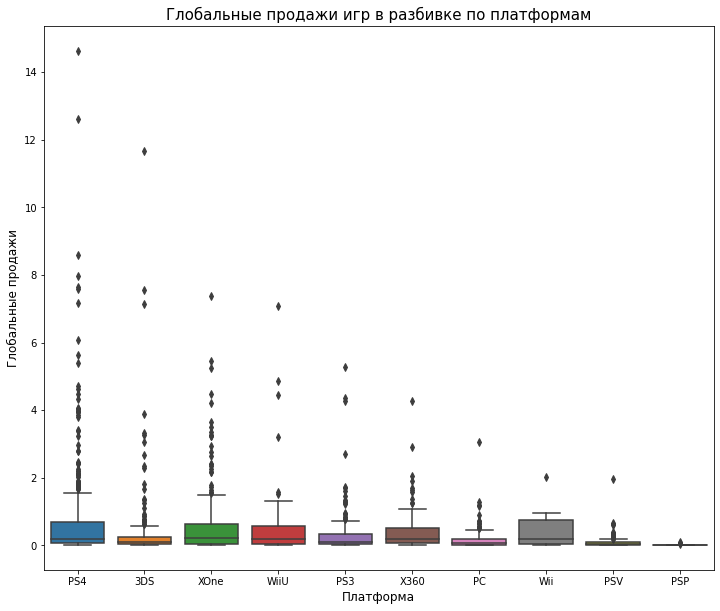

In [61]:
plt.figure(figsize=(12,10))
sns.boxplot(data=data_actual, x='platform', y='sales')
plt.title('Глобальные продажи игр в разбивке по платформам', fontsize=15)
plt.xlabel('Платформа', fontsize=12)
plt.ylabel('Глобальные продажи',fontsize=12)


_**Вывод:** Продажи на популярных платформах схожи. Медианные значения продаж у четырех X360, PS3, Wii, PS2 находятся близко к уровню 0,2, а в других 4 к уровню 0,1. На платформах 3DS,DS и PSP большая часть проданых игр лежит до значения в 0,5-0,6, на платформах PS4, Wii и PS2 до 0,85-1, а в лидерах X360 до 1,1 и в PS3 до 1,3млн_

### Продажи внутри одной популярной платформы и отзывы и Соотношение с другими платформами

Посмотрите, как влияют на продажи внутри одной популярной платформы отзывы пользователей и критиков. Постройте диаграмму рассеяния и посчитайте корреляцию между отзывами и продажами. Сформулируйте выводы.

#### Влияние Продажи-Отзывы на одной популярной платформе

In [62]:
top5_2017

['PS4', 'XOne', 'WiiU', 'PSV', '3DS']

Корреляция между оценками пользователей и продажами по платформе PS4  = -0.040131589472697356


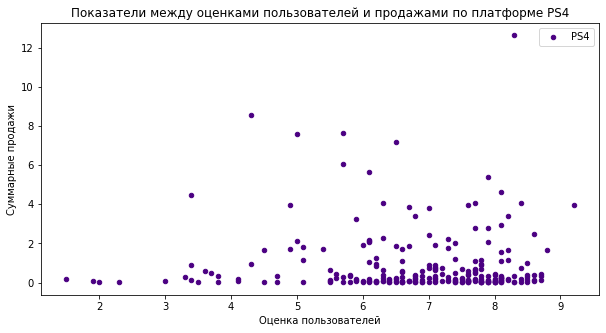

Корреляция между оценками пользователей и продажами по платформе XOne  = -0.0703839280647581


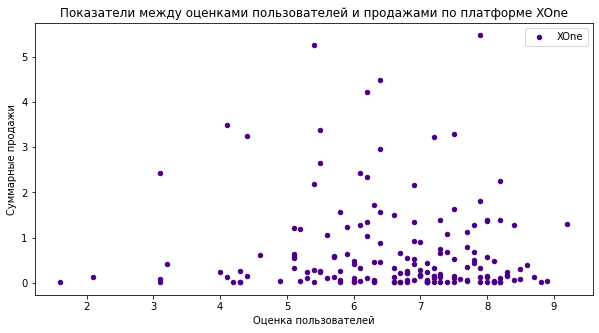

Корреляция между оценками пользователей и продажами по платформе WiiU  = 0.40792645792170773


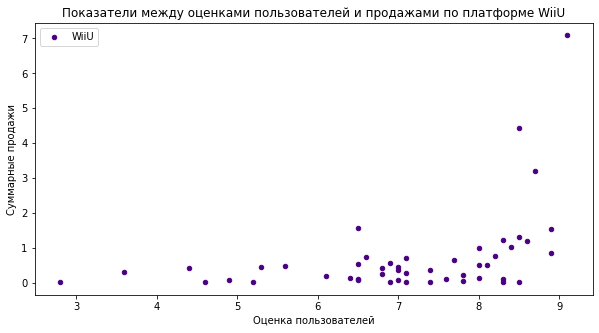

Корреляция между оценками пользователей и продажами по платформе PSV  = -0.16845504978064446


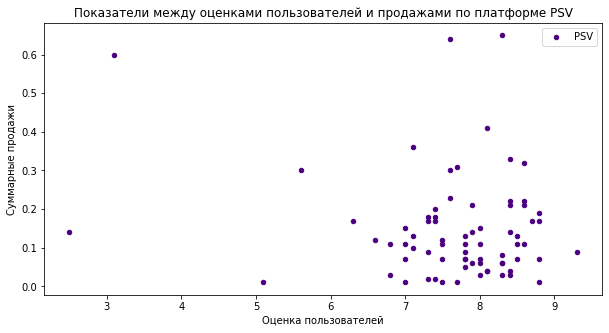

Корреляция между оценками пользователей и продажами по платформе 3DS  = 0.2151932718527028


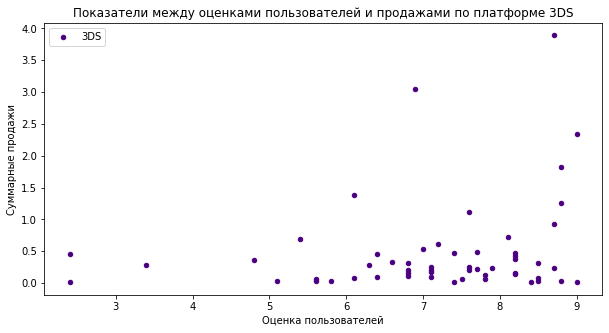

In [63]:
data_actual[data_actual['user_score'] != -1 ]
for name in top5_2017:
    (
    data_actual
        .query('platform == @name and user_score > -1')
        .plot(x='user_score', 
          y='sales', 
          kind='scatter', 
          figsize=(10, 5), 
          color='indigo')
    )
    plt.title(f'Показатели между оценками пользователей и продажами по платформе {name}')
    plt.xlabel('Оценка пользователей')
    plt.ylabel('Суммарные продажи')
    plt.legend([name])
    print(f'Корреляция между оценками пользователей и продажами по платформе {name}  =', data_actual.query('platform == @name and user_score > -1')['user_score'].corr(data_actual.query('platform == @name and user_score > -1')['sales']))
    plt.show()

Корреляция между оценками критиков и продажами по платформе PS4  = 0.40266141068104083


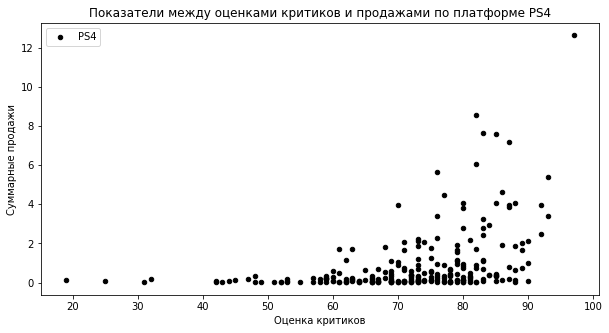

Корреляция между оценками критиков и продажами по платформе XOne  = 0.42867694370333226


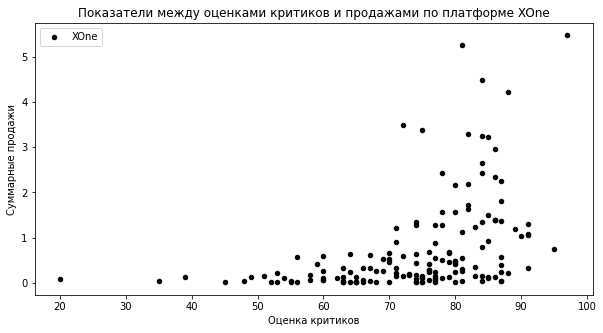

Корреляция между оценками критиков и продажами по платформе WiiU  = 0.370201412480884


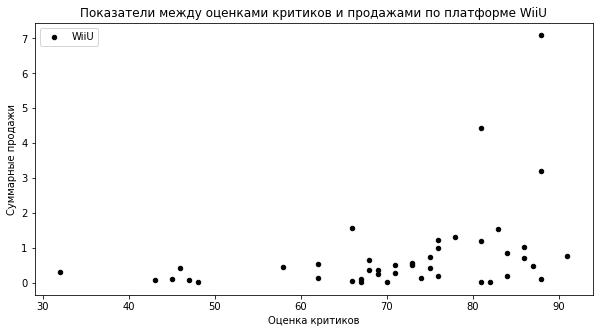

Корреляция между оценками критиков и продажами по платформе PSV  = 0.04266490657009526


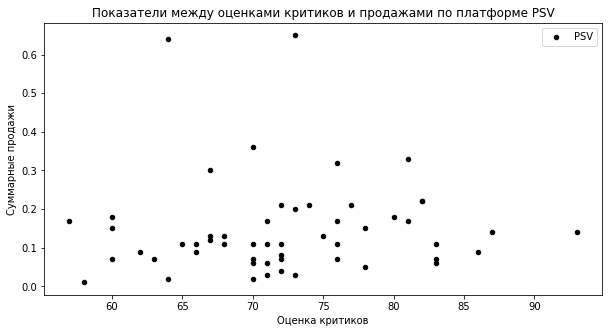

Корреляция между оценками критиков и продажами по платформе 3DS  = 0.314117492869051


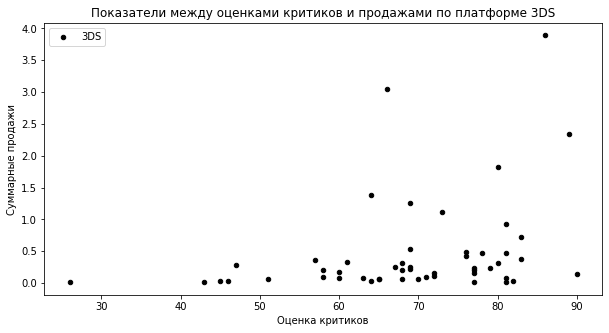

In [64]:
for name in top5_2017:
    (
    data_actual
        .query('platform == @name and critic_score > -1')
        .plot(x='critic_score', 
          y='sales', 
          kind='scatter', 
          figsize=(10, 5), 
          color='black')
    )
    plt.title(f'Показатели между оценками критиков и продажами по платформе {name}')
    plt.xlabel('Оценка критиков')
    plt.ylabel('Суммарные продажи')
    plt.legend([name])
    print(f'Корреляция между оценками критиков и продажами по платформе {name}  =', data_actual.query('platform == @name and critic_score > -1')['critic_score'].corr(data_actual.query('platform == @name and critic_score > -1')['sales']))
    plt.show()

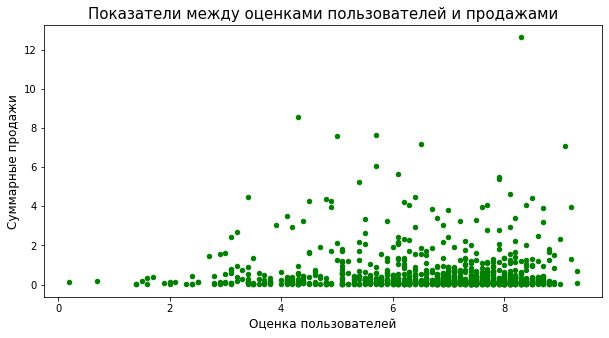

In [65]:
(
data_actual.query('user_score > -1')
    .plot(x='user_score', 
          y='sales', 
          kind='scatter', 
          figsize=(10, 5), 
          color='green')
)
plt.title('Показатели между оценками пользователей и продажами', fontsize=15)
plt.xlabel('Оценка пользователей', fontsize=12)
plt.ylabel('Суммарные продажи',fontsize=12)
plt.show()

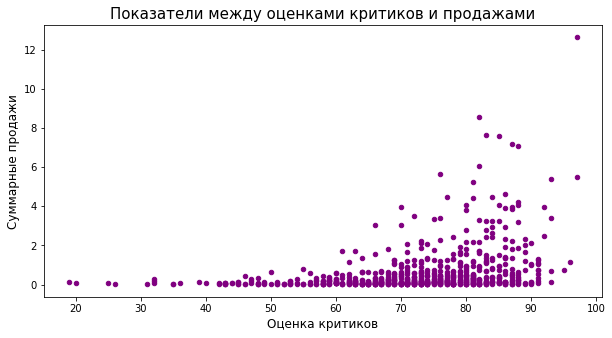

In [66]:
(
 data_actual.query('critic_score > -1')
    .plot(x='critic_score', 
          y='sales', 
          kind='scatter', 
          figsize=(10, 5), 
          color='purple')
)
plt.title('Показатели между оценками критиков и продажами', fontsize=15)
plt.xlabel('Оценка критиков', fontsize=12)
plt.ylabel('Суммарные продажи',fontsize=12)
plt.show()

Я решилась полностью этот раздел переделать. Получилось более наглядно.
Оценки пользователей абсолютно не влияют на продажи, но вот критики с хорошими отзывами чуть-чуть повышают продажи, но не настолько сильно, чтобы можно было говорить о прямом влияние.

_**Вывод:** По платформе X360: Отзывы критиков важны, хотя зависимость продаж от них находится на уровне средней на границе со слабой(коэффициент 0,39); зависимость здесь прямопропорцианальная - чем выше оценка, тем выше продажи. И зависимость продаж от отзывов пользователей, как выясняется слабая, но ближе к средней, также она прямопропорцианальная(хотя коэффициент значительно меньше - 0,115). В общем зависимости схожи._

#### Соотношение с другими платформами

In [67]:
top8

,platform,sales
0,PS4,288.15
1,XOne,140.36
2,3DS,86.68
3,PS3,68.18
4,X360,48.22
5,WiiU,42.98
6,PC,27.05
7,PSV,22.40


Создадим словарь sal_scor - Платформа:DataFrame (с продажами и отзывами)

In [68]:
sal_scor = {}
for p in top8['platform']:
    sal_scor[p] = df.query('platform==@p')[['sales', 'critic_score', 'user_score']].dropna().reset_index(drop=True)

Запишем в таблицу corr8 корелляции продаж с отзывами по топ8 платформам.

In [69]:
i=0
corr8 = pd.DataFrame(columns=['platform','crit_sale','user_sale'])
for pl_name in sal_scor.keys():
    corr8.loc[i, 'platform'] = pl_name
    corr8.loc[i, 'crit_sale'] = sal_scor[pl_name]['sales'].corr(sal_scor[pl_name]['critic_score'])
    corr8.loc[i, 'user_sale'] = sal_scor[pl_name]['sales'].corr(sal_scor[pl_name]['user_score'])
    i+=1

In [70]:
corr8

,platform,crit_sale,user_sale
0,PS4,0.343866,0.02911
1,XOne,0.35555,0.085258
2,3DS,0.290672,0.251866
3,PS3,0.320598,0.198749
4,X360,0.308289,0.165906
5,WiiU,0.337073,0.339053
6,PC,0.154099,0.064957
7,PSV,0.236122,0.131631


In [71]:
corr8

,platform,crit_sale,user_sale
0,PS4,0.343866,0.02911
1,XOne,0.35555,0.085258
2,3DS,0.290672,0.251866
3,PS3,0.320598,0.198749
4,X360,0.308289,0.165906
5,WiiU,0.337073,0.339053
6,PC,0.154099,0.064957
7,PSV,0.236122,0.131631


_**Вывод:** Схожие тенденции имеют место почти для всех платформ. Зависимость продаж пропорцианальная,- от отзывов критиков слабая но ближе к средней, а от отзывов пользователей значительно слабее, чем критиков, во многих её почти нет(более менее очень слабая зависимость присутствует в PSP, 3DS и PS2). Надо сказать об отдельных зависимостях: в PS4 - Пользователи не влияют на продажи, В Wii и DS зависимость Критиков очень слабая._

### Распределение игр по жанрам

Посмотрите на общее распределение игр по жанрам. Что можно сказать о самых прибыльных жанрах? Выделяются ли жанры с высокими и низкими продажами?

*Кол-во Игр в Жанрах*

In [72]:
game_genre =  data_actual.groupby('genre').agg({'name':'count'}).reset_index()
game_genre.sort_values(by='name', ascending=False)

,genre,name
0,Action,619
7,Role-Playing,221
1,Adventure,185
10,Sports,161
8,Shooter,128
3,Misc,113
6,Racing,69
2,Fighting,60
9,Simulation,44
4,Platform,38


Лидируют игры в жанре Action с большим отрывом.

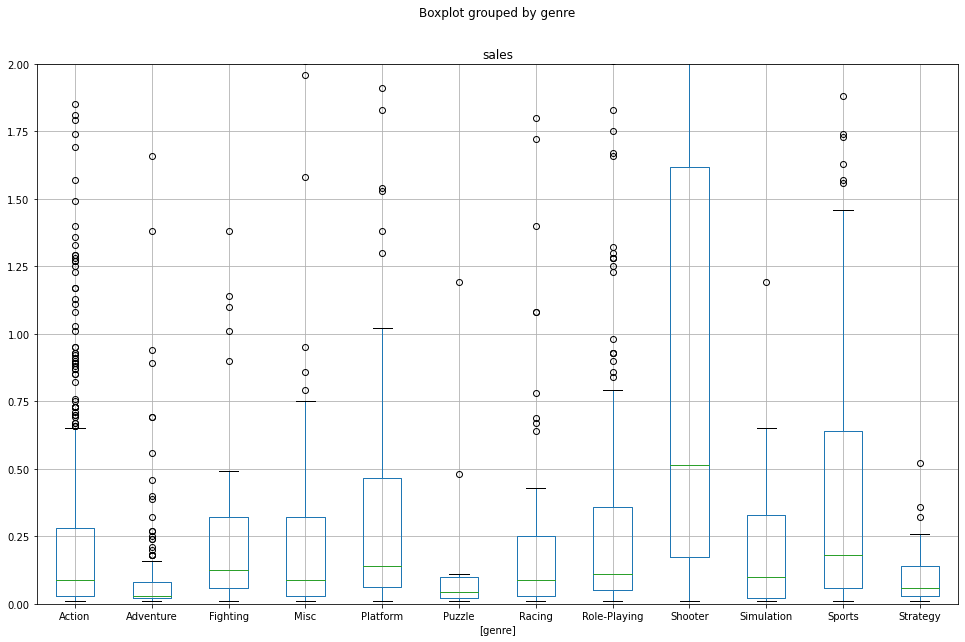

In [73]:
data_actual.boxplot(column = ['sales'],by = ['genre'],figsize=(16, 10))
plt.ylim([0, 2])
plt.show()

Жанр Action и тут отличился, в нем очень много выбросов. Значит в этом жанре много очень прибыльных игр. Из-за этого мы увидели, что общая прибыль по жанру Action лидирует, НО медиана продаж выше в жанре Shooter. Затем второе место делят между собой Platform и Sports.

## Шаг 4. Портрет пользователя каждого региона

Определите для пользователя каждого региона (NA, EU, JP):
* Самые популярные платформы (топ-5). Опишите различия в долях продаж.
* Самые популярные жанры (топ-5). Поясните разницу.
* Влияет ли рейтинг ESRB на продажи в отдельном регионе?

### Самые популярные платформы в регионах (топ-5)

Запишем в словарь popul_5platf_dict данные по продажам топ-5 платформ в 3 регионах {region:df}

In [74]:
popul_5platf_dict = {}
for region in ['na_sales', 'eu_sales', 'jp_sales']:
    popul_5platf_dict[region] = data_actual.groupby('platform')[region].sum().sort_values(ascending=False).head(5)
popul_5platf_dict

{'na_sales': platform
 PS4     98.61
 XOne    81.27
 X360    28.30
 3DS     22.64
 PS3     22.05
 Name: na_sales, dtype: float64,
 'eu_sales': platform
 PS4     130.04
 XOne     46.25
 PS3      25.54
 PC       17.97
 3DS      16.12
 Name: eu_sales, dtype: float64,
 'jp_sales': platform
 3DS     44.24
 PS4     15.02
 PSV     14.54
 PS3     11.22
 WiiU     7.31
 Name: jp_sales, dtype: float64}

Теперь отразим это все на графиках

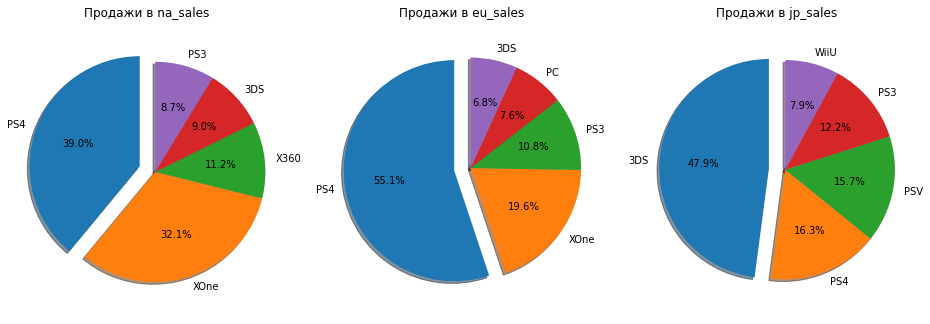

In [75]:
fig, (ax1, ax2, ax3) = plt.subplots(nrows=1, ncols=3, figsize=(16, 6))
fig.autofmt_xdate();

i = 0
x = [ax1, ax2, ax3]
region = ['na_sales', 'eu_sales', 'jp_sales']
explode = (0.15, 0, 0, 0, 0)

for i in [0,1,2]:
    labels = popul_5platf_dict[region[i]].index
    sizes = popul_5platf_dict[region[i]].values
    ax = x[i]
    ax.set_title(f'Продажи в {region[i]}')
    ax.pie(sizes, labels=labels, autopct='%1.1f%%', shadow=True, explode=explode,startangle=90) 
    ax.axis('equal')  

plt.show()


_**Вывод:** Лидеры продаж во всех регионах разные: Америка - X360, Европа - PS2 и Япония - DS. В Америке и Европе пользуются в основном одними и теми же 4 платформами - X360, PS2, Wii, PS3, исключение в Америке любят болше DS,а в Европе PS. В Японии совсем другая картина: тут более популярны платформы DS, SNES и 3DS. Надо отметить, что платформа PS2 очень популярна во всех регионах._

### Самые популярные жанры в регионах (топ-5)

Всё делаем по аналогии с пунктом 4.1
Запишем в словарь popul_5genre_dict данные по продажам топ-5 жанрам в 3 регионах {region:df}

In [76]:
popul_5genre_dict = {}
for region in ['na_sales', 'eu_sales', 'jp_sales']:
    popul_5genre_dict[region] = df.groupby('genre')[region].sum().sort_values(ascending=False).head(5)
popul_5genre_dict

{'na_sales': genre
 Action      863.17
 Sports      671.20
 Shooter     584.83
 Platform    444.44
 Misc        399.57
 Name: na_sales, dtype: float64,
 'eu_sales': genre
 Action     510.99
 Sports     371.33
 Shooter    314.52
 Racing     234.49
 Misc       210.60
 Name: eu_sales, dtype: float64,
 'jp_sales': genre
 Role-Playing    353.39
 Action          160.14
 Sports          134.93
 Platform        130.71
 Misc            107.02
 Name: jp_sales, dtype: float64}

Теперь отразим это все на графиках

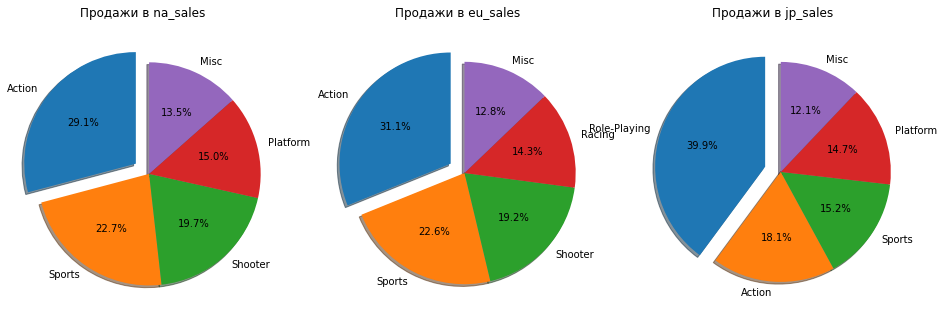

In [77]:
fig, (ax1, ax2, ax3) = plt.subplots(nrows=1, ncols=3, figsize=(16, 6))
fig.autofmt_xdate();

i = 0
x = [ax1, ax2, ax3]
region = ['na_sales', 'eu_sales', 'jp_sales']
explode = (0.15, 0, 0, 0, 0)

for i in [0,1,2]:
    labels = popul_5genre_dict[region[i]].index
    sizes = popul_5genre_dict[region[i]].values
    ax = x[i]
    ax.set_title(f'Продажи в {region[i]}')
    ax.pie(sizes, labels=labels, autopct='%1.1f%%', shadow=True, explode=explode,startangle=90) 
    ax.axis('equal')  

plt.show()

_**Вывод:** В Америке и Европе совпадают топ-3 жанра Action, Sports и Shoter, а также совпадает на 5 месте Misc(даже и в Японии тоже на 5 месте); различия на 4 месте в Америке Platform, а в Европе Racing. Наверно это можно объяснить общей культурой и менталитетом и конечно же языками - английский, испанский, французский, итальянский. В Японии же другая культура и язык совсем другой (больше 95% японцев в Японии говорят только на японском) поэтому и лидирует жанр Role-Playing, хотя тоже очень популярны Action и Sports, присутствует жанр Platform как и в Америке на 4 месте_

### Влияние рейтинга ESRB на продажи в отдельных регионах

In [78]:
esrb_sale = data_actual.groupby('rating')['na_sales', 'eu_sales', 'jp_sales'].sum().sort_values(by='na_sales', \
                                                                                       ascending=False).reset_index()
esrb_sale

/tmp/ipykernel_381/275226258.py:1: FutureWarning: Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.
  esrb_sale = data_actual.groupby('rating')['na_sales', 'eu_sales', 'jp_sales'].sum().sort_values(by='na_sales', \


,rating,na_sales,eu_sales,jp_sales
0,M,96.42,93.44,8.01
1,-1,64.72,58.95,56.90
2,E,50.74,58.06,8.94
3,T,38.95,34.07,14.78
4,E10+,33.23,26.16,4.46


* Справка:
https://ru.wikipedia.org/wiki/Entertainment_Software_Rating_Board
Entertainment Software Rating Board (ESRB) — негосударственная организация, основное направление деятельности — принятие и определение рейтингов для компьютерных видеоигр и другого развлекательного программного обеспечения в США и Канаде.

«E» («Everyone») — «Для всех»
«T» («Teen») — «Подросткам»
«M» («Mature») — «Для взрослых»
«E10+» («Everyone 10 and older») — «Для всех от 10 лет и старше»

«EC»(«K-A» - в ранних версиях с 1994-1997 годы) («Early childhood») — «Для детей младшего возраста»
«AO» («Adults Only 18+») — «Только для взрослых»
«RP» («Rating Pending») — «Рейтинг ожидается»

_**Вывод:** Существует (по нашей таблице) 4 основных рейтинга: «E»,«T»,«M» и «E10+» (4 другие очень не популярны, поэтому учитывать их в анализе нет смысла).Влияние рейтинга на продажи в разных регионах почти одинаково. На первом месте «E» и далее «T»,«M» и «E10+», исключение Европа, где продажи с рейтингом «M» на 13% больше, чем с «T». Да и доли этих рейтингов в своем регионе на вскидку тоже примерно одинаковы_

## Шаг 5. Проверка гипотез

* Средние пользовательские рейтинги платформ Xbox One и PC одинаковые;
* Средние пользовательские рейтинги жанров Action (англ. «действие», экшен-игры) и Sports (англ. «спортивные соревнования») разные.

### **Гипотеза** 1. Средние пользовательские рейтинги платформ Xbox One и PC одинаковые

Сформулируем нулевую (H0) и анльтернативную (H1) гипотезы:

* Н0: Средний пользовательский рейтинг платформ Xbox One и PC одинаковый
* H1: Средний пользовательский рейтинг платформ Xbox One и PC различается

In [79]:
#сразу зададим alpha
alpha = .05

In [80]:
#введём 2 переменных с данными оценок по Xbox One и PC
xbox_one = data_actual[(data_actual['platform'] == 'XOne') & (data_actual['user_score'] > 0)]['user_score']
pc = data_actual[(data_actual['platform'] == 'PC') & (data_actual['user_score'] > 0)]['user_score']

In [81]:
#проведём тест
results = st.ttest_ind(xbox_one, pc)

In [82]:
#выведем результат
print('p-значение:', results.pvalue)

if (results.pvalue < alpha):
    print("Отвергаем нулевую гипотезу")
else:
    print("Не получилось отвергнуть нулевую гипотезу")

p-значение: 0.10450507919348415
Не получилось отвергнуть нулевую гипотезу


С большой долей вероятности средние пользовательские рейтинги платформ XOne и PC не имеют статистически значимых отличий

### **Гипотеза** 2. Средние пользовательские рейтинги жанров Action и Sports разные

Сформулируем нулевую и альтернативную гипотезы:

* H0: Средние пользовательские рейтинги жанров Action и Sports одинаковы
* H1: Средние пользовательские рейтинги жанров Action и Sports разные

In [83]:
action = data_actual[(data_actual['genre'] == 'Action') & (data_actual['user_score'] > 0)]['user_score']
sport = data_actual[(data_actual['genre'] == 'Sports') & (data_actual['user_score'] > 0)]['user_score']

In [84]:
results = st.ttest_ind(action, sport)

In [85]:
#выведем результат
print('p-значение:', results.pvalue)

if (results.pvalue < alpha):
    print("Отвергаем нулевую гипотезу")
else:
    print("Не получилось отвергнуть нулевую гипотезу")

p-значение: 2.8711147985105864e-19
Отвергаем нулевую гипотезу


Средние пользовательские рейтинги жанров Action и Sports различаются.

## Общий вывод

**В ходе предобработки:**

* В cтолбце name удалено 2 строки , применяли лемматизацию для поиска схожих имен, но в итоге дубликатов не нашли

* Столбец year_of_release - Осталось 146 пропусков, удалять строки с ними не будем (пока), возможно пригодятся значения с продажами.

* Столбец critic_score и user_score заполнены на 8,7 тыс строк.

* Столбец rating - Удалось заполнить совсем не много - 437 пропусков.

* Оставшиеся пропуски заполнить не вижу возможности (логически/по_смыслу), если заполнять медианами, средними , то это может непредсказуемо отразиться на результатах будущего анализа данных.

* Дубликатов не выявленно

* Хоть данные очень не полные, придется оставить как есть. Будем использовать для анализа то, что имеем.

* По заданию добавлен столбец sales с суммой всех продаж в регионах

**В ходе анализа было выявлено:**

    Период до 1994 года характеризуется малой активностью. Хорошо видно, что важный период в релизах игр наступает в 1994 году - и после него начинается бум - компьютерные игры захватывают мир. В 2010 наступает переломный момент и уже в 2012 релизы падают в 2 раза и до 2016 держатся примерно на одном уровне

    Срок активного существования платформ 10-12 лет. Можно выделить из списка платформ - "PC" (компьютеры, наверное), они хоть и не в топах по выручке, но актуальны во все времена. Также надо отметить,что платформа "DS" просуществовала очень долго - до 2013 года.

    По прогнозу на 2017 год можно сказать: Флагманы - PS4 и XOne! PSV, WiiU и 3DS - тоже можно продолжать развивать, но в меньших объемах(PSV - развитие идет слабо, поэтому приоритет у WiiU и 3DS); платформа PC - актуальна всегда(но в малых объемах), поэтому надо поддерживать её развитие.

    Схожие тенденции имеют место почти для всех платформ. Зависимость продаж прямопропорцианальная,- от отзывов критиков слабая но ближе к средней, а от отзывов пользователей значительно слабее, чем критиков, во многих её почти нет(очень слабая зависимость присутствует в PSP, 3DS и PS2). Надо сказать об отдельных зависимостях: в PS4 - Пользователи не влияют на продажи, а в Wii и DS зависимость Критиков очень слабая.

    Общее распределение игр по жанрам - в тройку лидеров входят Action(20,2%), Sports(14%) и Sports(10,5%); аутсайдеры здесь Puzzle(3,5%), Strategy(4,1%) и Fighting(5,1%). В продажах по жанрам в лидерах опять Action(19,6%), Sports(14,9%), но на 3 месте уже Shooter(11,8); аутсайдеры здесь Strategy(2%), Puzzle(2,7%) как и в первом графике, но 3 место у Adventure(2,7%). Можно отметить, что продажи лидера Action и аутсайдера Strategy отличаются в 10 раз.

**Портрет пользователя каждого региона:**

    Лидеры продаж во всех регионах разные: Америка - X360, Европа - PS2 и Япония - DS. В Америке и Европе пользуются в основном одними и теми же 4 платформами - X360, PS2, Wii, PS3, исключение в Америке любят болше DS,а в Европе PS. В Японии совсем другая картина: тут более популярны платформы DS, SNES и 3DS. Надо отметить, что платформа PS2 очень популярна во всех регионах.

    В Америке и Европе совпадают топ-3 жанра Action, Sports и Shoter, а также совпадает на 5 месте Misc(даже и в Японии тоже на 5 месте); различия на 4 месте в Америке Platform, а в Европе Racing. В Японии же другая культура поэтому и лидирует жанр Role-Playing, хотя тоже очень популярны Action и Sports, присутствует жанр Platform как и в Америке на 4 месте

    Влияние рейтинга ESRB на продажи в разных регионах почти одинаково. На первом месте «E» и далее «T»,«M» и «E10+»

**Проверены гипотезы:**

* С большой долей вероятности средние пользовательские рейтинги платформ XOne и PC не имеют статистически значимых отличий

* Средние пользовательские рейтинги жанров Action и Sports различаются.
